# **CrediTrust Capital — Credit Risk Classification**
**Group 9 · BCADA 5P126 Machine Learning Lab · Final Lab Exam Project**

## 1. Problem Definition & Operational Framing

**Client:** CrediTrust Capital (Retail Banking)

**Business problem:** CrediTrust wants to predict whether a loan applicant is a **Good** or **Bad** credit risk, using the UCI Statlog German Credit dataset, so lending decisions can be made faster and more consistently.

**Why this matters operationally:** Approving a loan for someone who defaults (a **Type II error** / false negative) costs the business far more than rejecting a creditworthy applicant (a **Type I error** / false positive). This project explicitly weights **Type II errors 5x higher** than Type I errors.

**Success criteria:** Cost-Weighted F1 and Expected Loss — **not raw accuracy**, since accuracy alone hides how costly each type of mistake is.

## 2. Data Acquisition & Source Provenance

**Source:** UCI Statlog (German Credit Data), UCI Machine Learning Repository.
**Format:** 1,000 applicant records, 20 raw features (7 numeric, 13 categorical coded as `Axx`), 1 target column (`Credit_Risk`: 1 = Good, 2 = Bad).
**Access:** Dataset was pulled from the UCI repository and stored in the team's github repository, then loaded here.

# 3. Importing packages

In [177]:
import pandas as pd
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score

In [100]:
url = "https://raw.githubusercontent.com/SSRajeshwari-13/ML-Final-Lab-Group-09/refs/heads/main/data/german_credit%20(1).csv"
df = pd.read_csv(url)
df.head()

,Checking_Status,Duration_Months,Credit_History,Purpose,Credit_Amount,Savings_Status,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors_Guarantors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Dependents,Telephone,Foreign_Worker,Credit_Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


# 4. Data understanding

In [101]:
#gives the number of rows and columns present in the dataset
df.shape

(1000, 21)

In [102]:
#used to give statistical summary of numerical columns
df.describe()

,Duration_Months,Credit_Amount,Installment_Rate,Residence_Since,Age,Existing_Credits,Dependents,Credit_Risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Checking_Status           1000 non-null   object
 1   Duration_Months           1000 non-null   int64 
 2   Credit_History            1000 non-null   object
 3   Purpose                   1000 non-null   object
 4   Credit_Amount             1000 non-null   int64 
 5   Savings_Status            1000 non-null   object
 6   Employment_Since          1000 non-null   object
 7   Installment_Rate          1000 non-null   int64 
 8   Personal_Status_Sex       1000 non-null   object
 9   Other_Debtors_Guarantors  1000 non-null   object
 10  Residence_Since           1000 non-null   int64 
 11  Property                  1000 non-null   object
 12  Age                       1000 non-null   int64 
 13  Other_Installment_Plans   1000 non-null   object
 14  Housing                  

In [104]:
print("Target class distribution:")
print(df['Credit_Risk'].value_counts())
print()
print(df['Credit_Risk'].value_counts(normalize=True).round(3))

Target class distribution:
Credit_Risk
1    700
2    300
Name: count, dtype: int64

Credit_Risk
1    0.7
2    0.3
Name: proportion, dtype: float64


**Observation:** the target is imbalanced — roughly 70% Good (1) vs. 30% Bad (2). This is why accuracy alone is a poor metric here; a model can score well on accuracy just by favoring the majority class.

# 5. Data Cleaning & Sanitization (Data Engineer)
### Checks for missing values, duplicates, invalid records, and schema conformity before anything else happens.

In [105]:
#used to find missing values in each column
df.isnull().sum()

,0
Checking_Status,0
Duration_Months,0
Credit_History,0
Purpose,0
Credit_Amount,0
Savings_Status,0
Employment_Since,0
Installment_Rate,0
Personal_Status_Sex,0
Other_Debtors_Guarantors,0


In [106]:
#used to find duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

In [107]:
#used to drop the duplicate values from the dataset
df=df.drop_duplicates()
df

,Checking_Status,Duration_Months,Credit_History,Purpose,Credit_Amount,Savings_Status,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors_Guarantors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Dependents,Telephone,Foreign_Worker,Credit_Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2


In [108]:
expected_columns = [
    'Checking_Status',
    'Duration_Months',
    'Credit_History',
    'Purpose',
    'Credit_Amount',
    'Savings_Status',
    'Employment_Since',
    'Installment_Rate',
    'Personal_Status_Sex',
    'Other_Debtors_Guarantors',
    'Residence_Since',
    'Property',
    'Age',
    'Other_Installment_Plans',
    'Housing',
    'Existing_Credits',
    'Job',
    'Dependents',
    'Telephone',
    'Foreign_Worker',
    'Credit_Risk'
]

print("Number of columns:", len(df.columns))

print("Missing expected columns:",
      set(expected_columns) - set(df.columns))

Number of columns: 21
Missing expected columns: set()


In [109]:
numeric_columns = [
    'Duration_Months',
    'Credit_Amount',
    'Installment_Rate',
    'Residence_Since',
    'Age',
    'Existing_Credits',
    'Dependents'
]

print(df[numeric_columns].describe())

       Duration_Months  Credit_Amount  Installment_Rate  Residence_Since  \
count      1000.000000    1000.000000       1000.000000      1000.000000   
mean         20.903000    3271.258000          2.973000         2.845000   
std          12.058814    2822.736876          1.118715         1.103718   
min           4.000000     250.000000          1.000000         1.000000   
25%          12.000000    1365.500000          2.000000         2.000000   
50%          18.000000    2319.500000          3.000000         3.000000   
75%          24.000000    3972.250000          4.000000         4.000000   
max          72.000000   18424.000000          4.000000         4.000000   

               Age  Existing_Credits   Dependents  
count  1000.000000       1000.000000  1000.000000  
mean     35.546000          1.407000     1.155000  
std      11.375469          0.577654     0.362086  
min      19.000000          1.000000     1.000000  
25%      27.000000          1.000000     1.000000  
50%

In [110]:
# Validity checks
print("Age below 18:", (df['Age'] < 18).sum())
print("Credit amount <= 0:", (df['Credit_Amount'] <= 0).sum())
print("Duration <= 0:", (df['Duration_Months'] <= 0).sum())

Age below 18: 0
Credit amount <= 0: 0
Duration <= 0: 0


## Outlier Detection (IQR method)

In [111]:
def find_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return outliers, lower, upper

In [112]:
for col in ['Credit_Amount', 'Duration_Months', 'Age']:
    outliers, lower, upper = find_outliers(df, col)

    print("\nColumn:", col)
    print("Lower limit:", lower)
    print("Upper limit:", upper)
    print("Number of outliers:", len(outliers))


Column: Credit_Amount
Lower limit: -2544.625
Upper limit: 7882.375
Number of outliers: 72

Column: Duration_Months
Lower limit: -6.0
Upper limit: 42.0
Number of outliers: 70

Column: Age
Lower limit: 4.5
Upper limit: 64.5
Number of outliers: 23


**Decision on outliers:** `Duration_Months` and `Credit_Amount` outliers show a Bad-risk rate roughly **1.8x the baseline** (54–57% vs 30%) — this is meaningful signal, not noise, so these rows are **kept**. Applicants with unusually long or large loans are genuinely higher risk, which is exactly the kind of pattern the model needs to learn. `Age` outliers do not show an elevated risk rate and are also kept, as extreme ages are still valid, real applicants.

# 6. Splitting dataset for training and testing

Separating features and target variables

In [113]:
X = df.drop('Credit_Risk', axis=1)
y = df['Credit_Risk']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 20)
Target shape: (1000,)


In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 20)
Testing data: (200, 20)


Identifying Categorical variables

In [115]:
categorical_columns = X_train.select_dtypes(
    include=['object']
).columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['Checking_Status', 'Credit_History', 'Purpose', 'Savings_Status', 'Employment_Since', 'Personal_Status_Sex', 'Other_Debtors_Guarantors', 'Property', 'Other_Installment_Plans', 'Housing', 'Job', 'Telephone', 'Foreign_Worker']


Identifying Numerical variables

In [116]:
numerical_columns = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['Duration_Months', 'Credit_Amount', 'Installment_Rate', 'Residence_Since', 'Age', 'Existing_Credits', 'Dependents']


# 7. Scaling and One-hot Encoding

In [117]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ]
)

In [118]:
#fit → learns the required information from the training data
#transform → applies scaling and one-hot encoding to the training data
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training data processed successfully")
print("Testing data processed successfully")

Training data processed successfully
Testing data processed successfully


In [119]:
#converts the processed data back into a Pandas DataFrame and gives the columns proper names.
# 61 columns because one hot encoding has expanded the categorical columns
feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (800, 61)
Processed testing data: (200, 61)


In [120]:
## Saving train and test files
print(os.getcwd())

/content


In [121]:
# Create processed folder
os.makedirs("data/processed", exist_ok=True)

# Add target column
train_data = X_train_processed.copy()
train_data["Credit_Risk"] = y_train.values

test_data = X_test_processed.copy()
test_data["Credit_Risk"] = y_test.values

# Save files
train_data.to_csv("data/processed/train.csv", index=False)
test_data.to_csv("data/processed/test.csv", index=False)

print("Train and test files saved successfully!")

Train and test files saved successfully!


In [122]:
print(os.listdir("data/processed"))

['data_quality_log.csv', 'X_test_processed.csv', 'test.csv', 'X_train_processed.csv', 'train.csv']


# 8. Quality Log

In [123]:
#A Quality Log is basically a record of all the checks you performed on your dataset before giving it to the Machine Learning team.
quality_log = pd.DataFrame({
    'Check': [
        'Number of rows',
        'Number of columns',
        'Missing values',
        'Duplicate rows',
        'Training Set',
        'Testing  Set'
    ],
    'Result': [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        len(X_train),
        len(X_test)
    ]
})

print(quality_log)

               Check  Result
0     Number of rows    1000
1  Number of columns      21
2     Missing values       0
3     Duplicate rows       0
4       Training Set     800
5       Testing  Set     200


In [124]:
# Saving quality log
quality_log.to_csv(
    "data/processed/data_quality_log.csv",
    index=False
)

print("Data quality log saved!")

Data quality log saved!


Loading cleaned dataset

In [125]:
train_data = pd.read_csv("/content/data/processed/train.csv")
test_data = pd.read_csv("/content/data/processed/test.csv")

In [126]:
train_data.head()

,num__Duration_Months,num__Credit_Amount,num__Installment_Rate,num__Residence_Since,num__Age,num__Existing_Credits,num__Dependents,cat__Checking_Status_A11,cat__Checking_Status_A12,cat__Checking_Status_A13,...,cat__Housing_A153,cat__Job_A171,cat__Job_A172,cat__Job_A173,cat__Job_A174,cat__Telephone_A191,cat__Telephone_A192,cat__Foreign_Worker_A201,cat__Foreign_Worker_A202,Credit_Risk
0,1.289592,1.925766,0.052281,1.053413,1.057784,-0.718745,-0.436436,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2
1,-0.742595,-0.892853,0.942164,1.053413,0.242449,-0.718745,-0.436436,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1
2,1.289592,0.816433,0.052281,-0.747293,-0.663479,1.045047,-0.436436,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1
3,1.289592,0.299568,0.052281,-0.747293,-0.572886,-0.718745,-0.436436,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
4,2.305686,1.982655,-1.727486,-0.747293,-1.025850,-0.718745,-0.436436,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1


In [127]:
test_data.head()

,num__Duration_Months,num__Credit_Amount,num__Installment_Rate,num__Residence_Since,num__Age,num__Existing_Credits,num__Dependents,cat__Checking_Status_A11,cat__Checking_Status_A12,cat__Checking_Status_A13,...,cat__Housing_A153,cat__Job_A171,cat__Job_A172,cat__Job_A173,cat__Job_A174,cat__Telephone_A191,cat__Telephone_A192,cat__Foreign_Worker_A201,cat__Foreign_Worker_A202,Credit_Risk
0,-0.234548,-0.477788,0.052281,0.153060,0.061263,-0.718745,-0.436436,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1
1,-0.742595,-0.497625,0.942164,-0.747293,-0.119922,1.045047,-0.436436,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1
2,0.273499,-0.810513,0.942164,1.053413,1.148377,-0.718745,-0.436436,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2
3,-0.234548,-0.032034,0.052281,-1.647646,-0.391701,-0.718745,-0.436436,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1
4,0.527522,-0.250607,0.942164,-0.747293,-1.116443,1.045047,-0.436436,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,2


In [128]:
os.makedirs("data/processed", exist_ok=True)

X_train_processed.to_csv(
    "data/processed/X_train_processed.csv",
    index=False
)

print("Training CSV saved successfully!")

Training CSV saved successfully!


In [129]:
X_test_processed.to_csv(
    "data/processed/X_test_processed.csv",
    index=False
)

print("Testing CSV saved successfully!")

Testing CSV saved successfully!


In [130]:
print(os.listdir("data/processed"))

['data_quality_log.csv', 'X_test_processed.csv', 'test.csv', 'X_train_processed.csv', 'train.csv']


In [131]:
shutil.make_archive("cleaned_credit_data", "zip", "data/processed")
files.download("cleaned_credit_data.zip")
print("Downloaded successfully")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded successfully


## 9. Exploratory Data Analysis (Data Analyst)
Visual and statistical exploration to surface non-trivial patterns before modeling.

In [132]:
target = "Credit_Risk"
print(train_data[target].value_counts())

Credit_Risk
1    560
2    240
Name: count, dtype: int64


### Visual EDA – Target Distribution

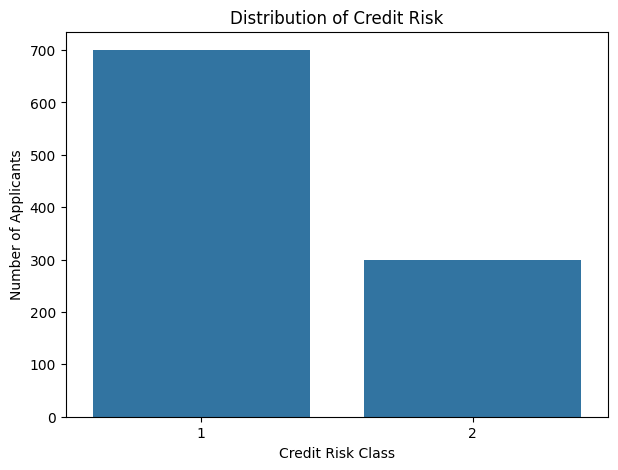

In [133]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Credit_Risk"
)

plt.title("Distribution of Credit Risk")
plt.xlabel("Credit Risk Class")
plt.ylabel("Number of Applicants")

plt.show()

### Observation

The target variable is imbalanced, with Class 1 representing approximately 70% of observations and Class 2 approximately 30%.
Therefore, model evaluation should consider class-specific metrics such as precision, recall and F1-score rather than relying only on accuracy.

In [134]:
numeric_columns = train_data.select_dtypes(include=np.number).columns
print("Number of numerical columns after encoding:",len(numeric_columns))

Number of numerical columns after encoding: 62


Distribution Plots

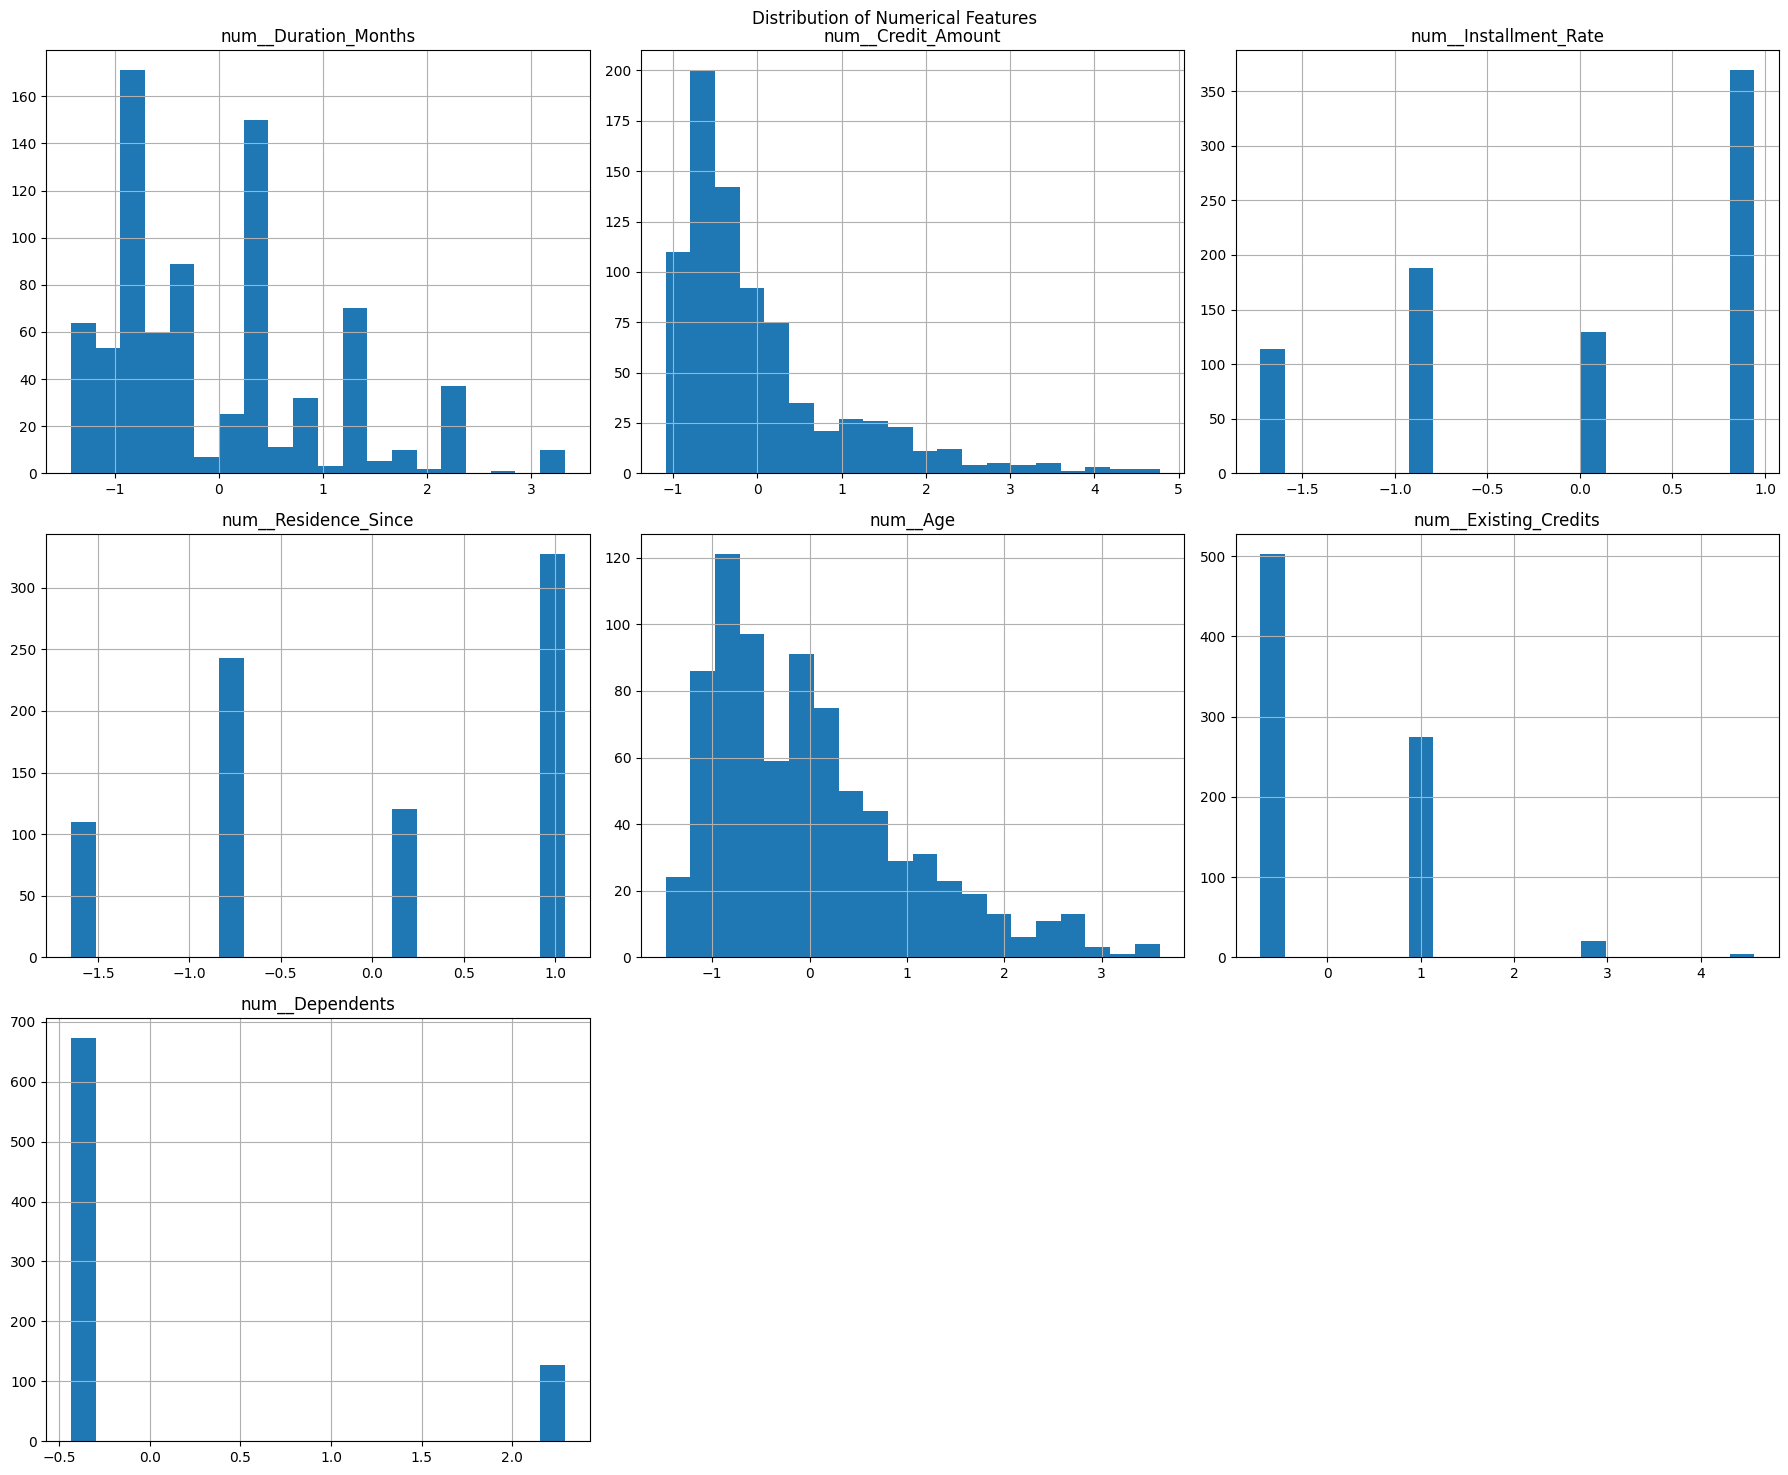

In [135]:
numeric_columns = [
    "num__Duration_Months",
    "num__Credit_Amount",
    "num__Installment_Rate",
    "num__Residence_Since",
    "num__Age",
    "num__Existing_Credits",
    "num__Dependents"
]

train_data[numeric_columns].hist(
    figsize=(18, 15),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

Skewness Analysis

In [136]:
numeric_columns = [
    "num__Duration_Months",
    "num__Credit_Amount",
    "num__Installment_Rate",
    "num__Residence_Since",
    "num__Age",
    "num__Existing_Credits",
    "num__Dependents"
]

skewness = train_data[numeric_columns].skew()

skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

skewness_df = skewness_df.sort_values(
    by="Skewness",
    ascending=False
)

display(skewness_df)

,Feature,Skewness
6,num__Dependents,1.858338
1,num__Credit_Amount,1.826435
5,num__Existing_Credits,1.192207
0,num__Duration_Months,1.046744
4,num__Age,1.043352
3,num__Residence_Since,-0.263938
2,num__Installment_Rate,-0.487842


Skewness Plot

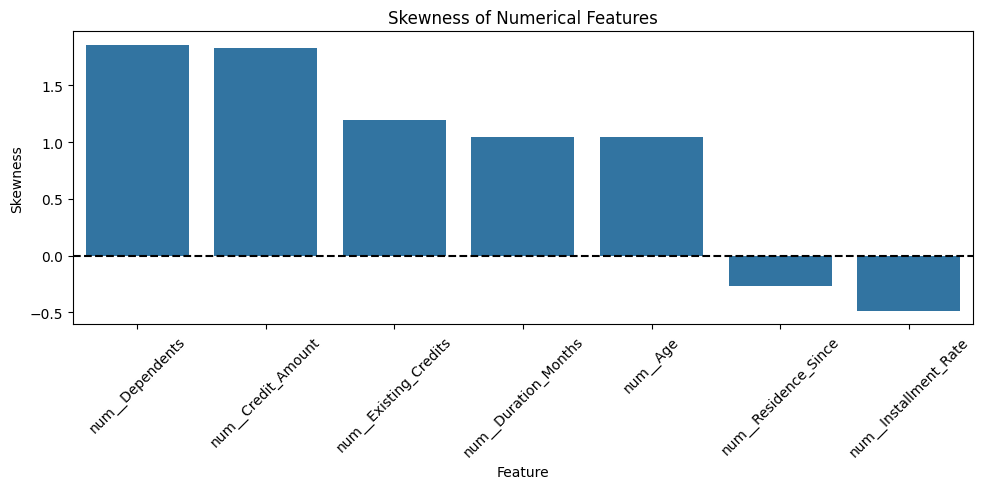

In [137]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=skewness_df,
    x="Feature",
    y="Skewness"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.title("Skewness of Numerical Features")
plt.xlabel("Feature")
plt.ylabel("Skewness")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The skewness analysis shows that the numerical variables do not all follow symmetric distributions. Some variables exhibit stronger skewness than others.
Credit Amount shows noticeable variation and skewness, indicating that loan amounts are not uniformly distributed across applicants.

### Boxplots – Anomaly / Outlier Detection

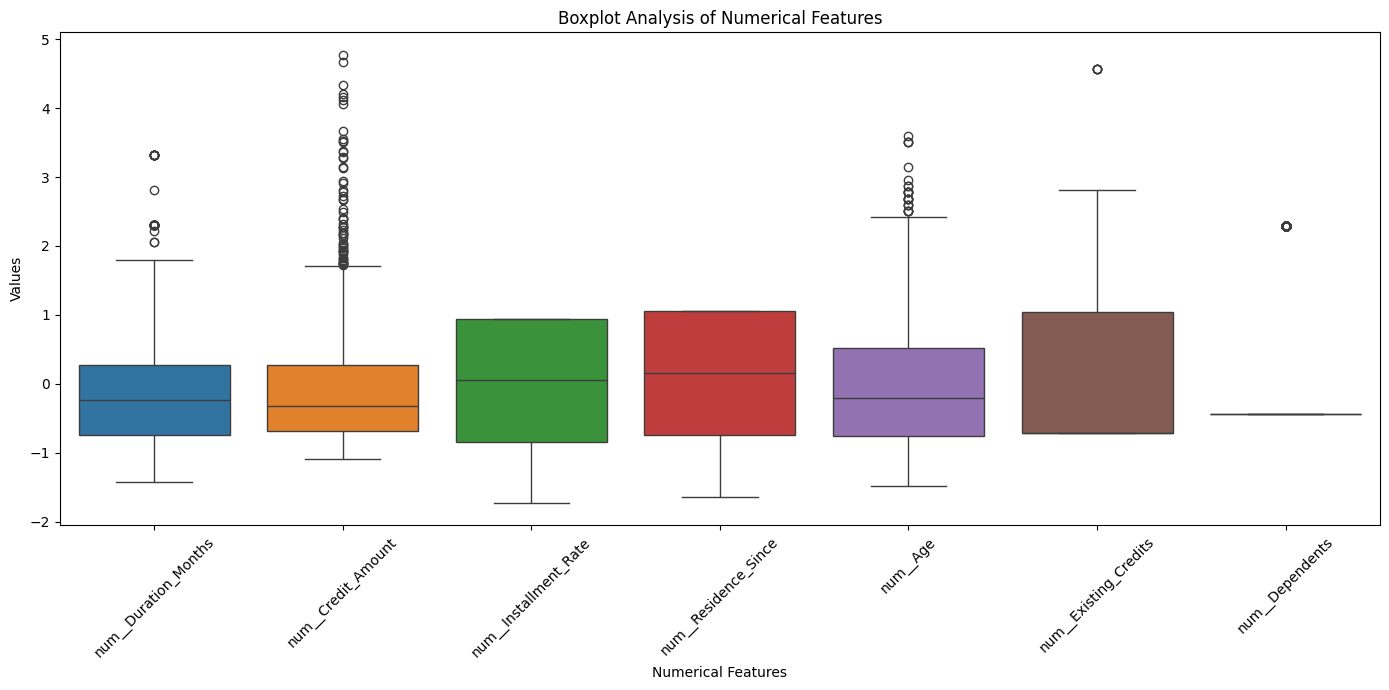

In [138]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=train_data[numeric_columns]
)

plt.title("Boxplot Analysis of Numerical Features")
plt.xlabel("Numerical Features")
plt.ylabel("Values")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The boxplots indicate the presence of potential extreme observations in some numerical variables, particularly in variables such as Credit Amount and Duration.
These observations are not automatically removed because they may represent legitimate applicants with unusually large loan amounts or longer loan durations.

### Correlation Analysis

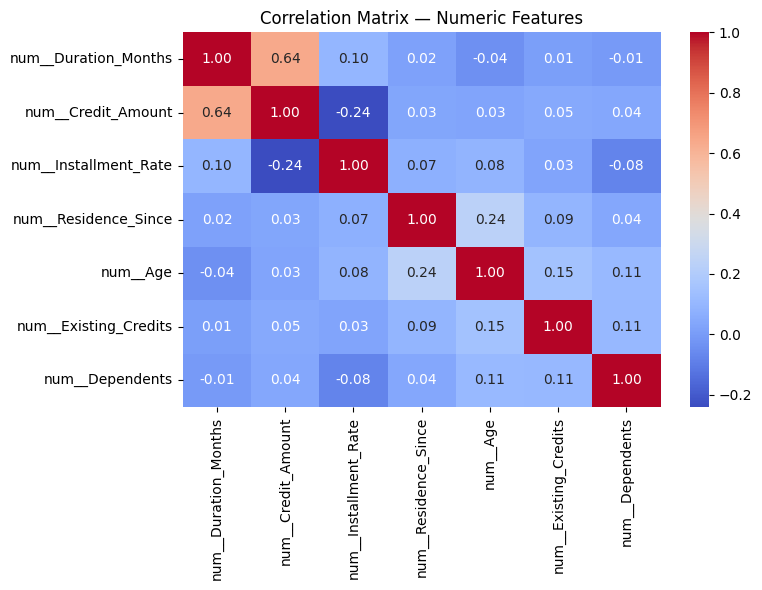

In [141]:
correlation = train_data[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

Find Strongest Feature Correlations

In [142]:
corr_pairs = (
    correlation
    .where(
        np.triu(
            np.ones(correlation.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

corr_pairs["Absolute_Correlation"] = (
    corr_pairs["Correlation"].abs()
)

corr_pairs = corr_pairs.sort_values(
    by="Absolute_Correlation",
    ascending=False
)

display(
    corr_pairs.head(10)
)

,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,num__Duration_Months,num__Credit_Amount,0.637919,0.637919
6,num__Credit_Amount,num__Installment_Rate,-0.240906,0.240906
15,num__Residence_Since,num__Age,0.238072,0.238072
18,num__Age,num__Existing_Credits,0.147695,0.147695
19,num__Age,num__Dependents,0.112609,0.112609
20,num__Existing_Credits,num__Dependents,0.107288,0.107288
1,num__Duration_Months,num__Installment_Rate,0.097973,0.097973
16,num__Residence_Since,num__Existing_Credits,0.090161,0.090161
12,num__Installment_Rate,num__Age,0.084367,0.084367
14,num__Installment_Rate,num__Dependents,-0.077311,0.077311


### Observation

The correlation analysis helps identify numerical variables that have stronger relationships with each other.
Most numerical variables show relatively weak pairwise relationships, while a few feature pairs exhibit stronger associations.

## Credit Amount vs Age

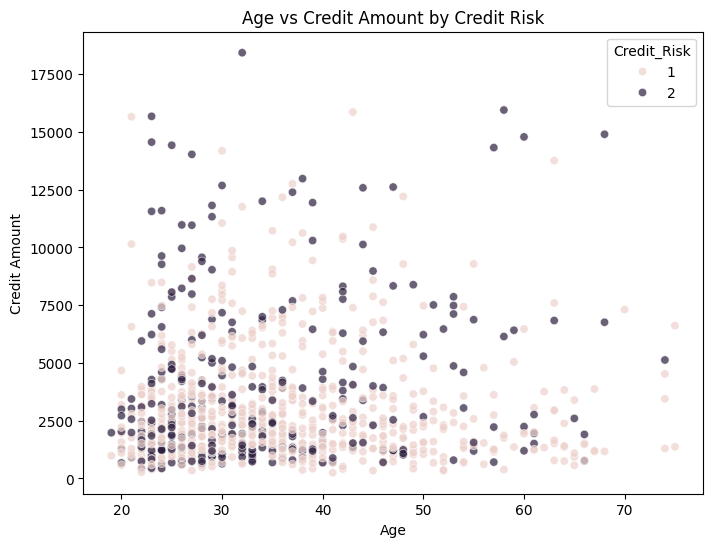

In [143]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Credit_Amount",
    hue="Credit_Risk",
    alpha=0.7
)

plt.title("Age vs Credit Amount by Credit Risk")
plt.xlabel("Age")
plt.ylabel("Credit Amount")

plt.show()

### Observation

There is substantial overlap between the credit-risk classes across Age and Credit Amount.
Therefore, Age and Credit Amount alone do not clearly separate the two risk classes.

## Credit Amount by Credit Risk

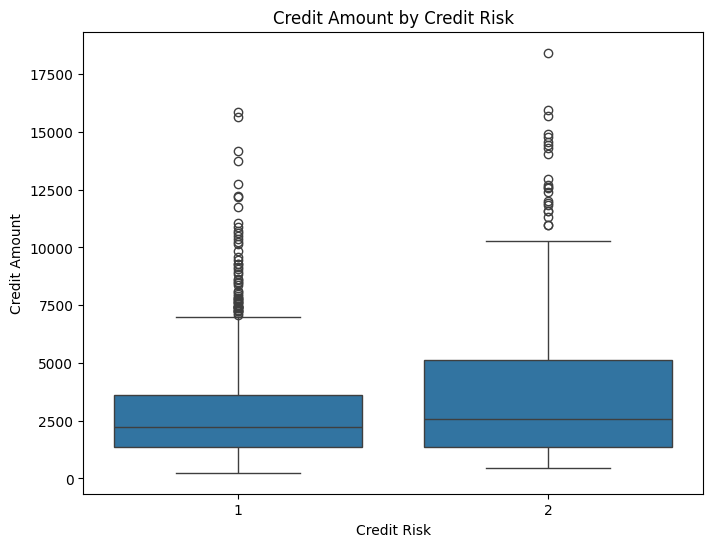

In [144]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Credit_Risk",
    y="Credit_Amount"
)

plt.title("Credit Amount by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Credit Amount")

plt.show()

### Observation

Class 2 shows somewhat higher variation in Credit Amount compared with Class 1. However, there is substantial overlap between the two classes.

## Duration vs Credit Risk

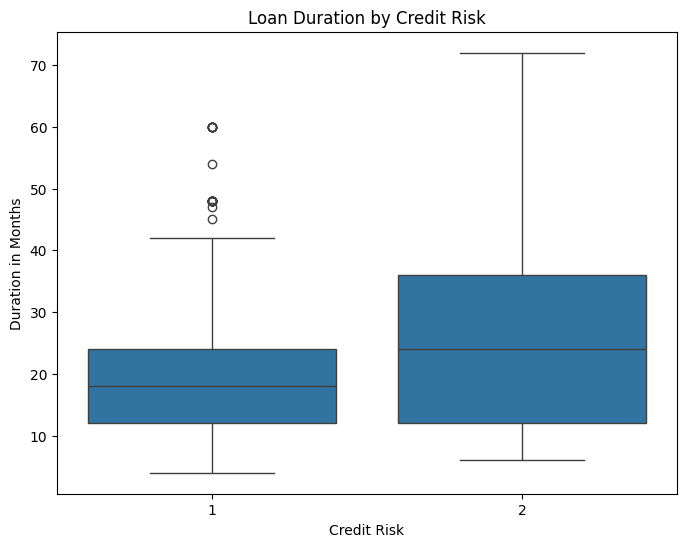

In [145]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Credit_Risk",
    y="Duration_Months"
)

plt.title("Loan Duration by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Duration in Months")

plt.show()

### Observation

Loan duration shows a meaningful association with credit risk and should therefore be considered as an important feature during model development.

## Checking Status vs Credit Risk

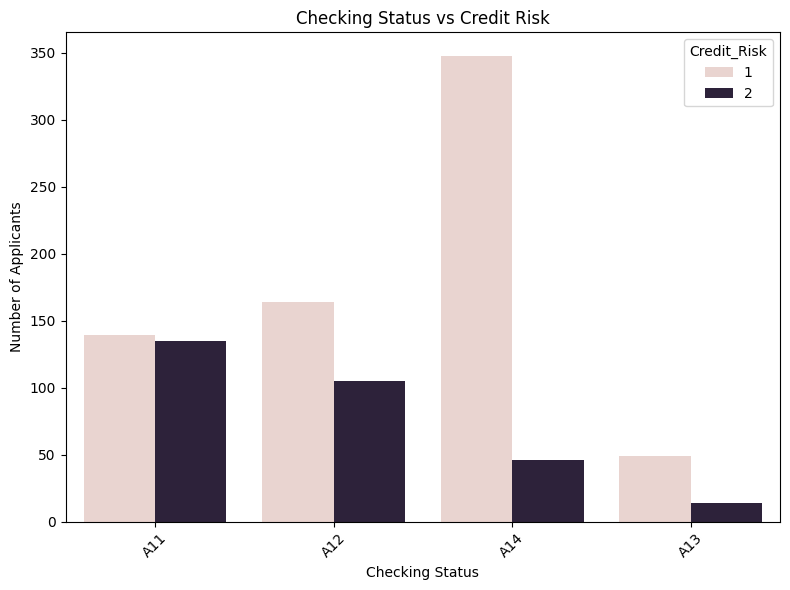

In [146]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="Checking_Status",
    hue="Credit_Risk"
)

plt.title("Checking Status vs Credit Risk")
plt.xlabel("Checking Status")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The distribution of credit-risk classes differs across checking-status categories.
This indicates that Checking Status contains useful information for distinguishing between credit-risk classes.

## Top Features Associated with Credit Risk

In [147]:
target_correlation = (
    train_data[numeric_columns + ["Credit_Risk"]]
    .corr()["Credit_Risk"]
    .drop("Credit_Risk")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("Numerical features most associated with Credit Risk:")
display(target_correlation.to_frame("Correlation"))

Numerical features most associated with Credit Risk:


,Correlation
num__Duration_Months,0.206301
num__Credit_Amount,0.138776
num__Installment_Rate,0.080345
num__Age,-0.057750
num__Existing_Credits,-0.047149
num__Dependents,0.011905
num__Residence_Since,0.001965


# 10. Top 3 Actionable Data Insights
### Insight 1 – Class Imbalance

The target variable is imbalanced, with approximately 70% of observations belonging to Class 1 and 30% belonging to Class 2.

**Action:** Model evaluation should use class-aware metrics such as precision, recall and F1-score in addition to accuracy. The class distribution should also be monitored during model development.

---

### Insight 2 – Checking Status and Credit Risk

Checking Status shows a noticeable relationship with Credit Risk, with some checking-status categories being more strongly associated with the target than others.

**Action:** Checking Status should be retained as an important categorical feature during model development and should be properly encoded before training.

---

### Insight 3 – Loan Duration and Credit Amount

Loan Duration and Credit Amount show useful relationships with credit risk. Credit Amount also exhibits substantial variation and potential extreme observations.

**Action:** These variables should be retained during modelling, while their distributions and extreme values should be monitored during preprocessing and model evaluation.

#Data Scientist

## 11. Feature Engineering, Encoding & Selection

Numeric features are scaled; categorical features are one-hot encoded (all are nominal with no inherent order in this simplified treatment — see project notes for the ordinal alternative considered for `Checking_Status`, `Savings_Status`, `Employment_Since`).

In [148]:
target = "Credit_Risk"

X_train = train_data.drop(columns=[target])
y_train = train_data[target]

X_test = test_data.drop(columns=[target])
y_test = test_data[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTarget classes:")
print(y_train.value_counts())

X_train shape: (800, 61)
X_test shape: (200, 61)
y_train shape: (800,)
y_test shape: (200,)

Target classes:
Credit_Risk
1    560
2    240
Name: count, dtype: int64


**The objective is to predict Credit Risk using supervised machine learning**.

The following classification algorithms will be evaluated:

1. Logistic Regression - baseline model
2. Decision Tree - interpretable non-linear model
3. Random Forest - ensemble model
4. Gradient Boosting - boosting-based candidate model

The models will be compared using:
- Accuracy
- Precision
- Recall
- F1-score
- Cross-validation score

## 12. Training the ML models

* Baseline model - **Logistic Regression**

In [149]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


**Predictions**

In [150]:
y_pred_logistic = logistic_model.predict(X_test)

print("Predictions generated successfully.")

print("\nFirst 20 predictions:")
print(y_pred_logistic[:20])

Predictions generated successfully.

First 20 predictions:
[1 1 2 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1]


**Evaluation of Logistic Regression**

In [151]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic, pos_label=2)
recall = recall_score(y_test, y_pred_logistic, pos_label=2)
f1 = f1_score(y_test, y_pred_logistic, pos_label=2)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
--------------------------------
Accuracy : 0.78
Precision: 0.6666666666666666
Recall   : 0.5333333333333333
F1 Score : 0.5925925925925926

Classification Report:
              precision    recall  f1-score   support

           1       0.82      0.89      0.85       140
           2       0.67      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



* **Decision Tree**

In [152]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)
print("Decision Tree trained successfully.")

Decision Tree trained successfully.


**Evaluation of Decision Tree**

In [153]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, pos_label=2)
recall_dt = recall_score(y_test, y_pred_dt, pos_label=2)
f1_dt = f1_score(y_test, y_pred_dt, pos_label=2)

print("Decision Tree Results")
print("--------------------------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree Results
--------------------------------
Accuracy : 0.63
Precision: 0.3793103448275862
Recall   : 0.36666666666666664
F1 Score : 0.3728813559322034


* **Random Forest**

In [154]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
print("Random Forest trained successfully.")

Random Forest trained successfully.


**Evaluation of Random Forest**

In [155]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label=2)
recall_rf = recall_score(y_test, y_pred_rf, pos_label=2)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=2)

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Results
--------------------------------
Accuracy : 0.74
Precision: 0.6052631578947368
Recall   : 0.38333333333333336
F1 Score : 0.46938775510204084


* **Gradient Boosting**

In [156]:
gradient_boosting = GradientBoostingClassifier(random_state=42)
gradient_boosting.fit(X_train, y_train)
y_pred_gb = gradient_boosting.predict(X_test)
print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


**Evaluation of Gradient Boosting**

In [157]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, pos_label=2)
recall_gb = recall_score(y_test, y_pred_gb, pos_label=2)
f1_gb = f1_score(y_test, y_pred_gb, pos_label=2)

print("Gradient Boosting Results")
print("--------------------------------")
print("Accuracy :", accuracy_gb)
print("Precision:", precision_gb)
print("Recall   :", recall_gb)
print("F1 Score :", f1_gb)

Gradient Boosting Results
--------------------------------
Accuracy : 0.79
Precision: 0.68
Recall   : 0.5666666666666667
F1 Score : 0.6181818181818182


### Comparing All Models

*   Logistic Regression
*   Decision Tree
*   Random Forest
*   Gradient Boosting

In [158]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf,
        accuracy_gb
    ],
    "Precision": [
        precision,
        precision_dt,
        precision_rf,
        precision_gb
    ],
    "Recall": [
        recall,
        recall_dt,
        recall_rf,
        recall_gb
    ],
    "F1 Score": [
        f1,
        f1_dt,
        f1_rf,
        f1_gb
    ]
})

display(results.sort_values("F1 Score", ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score
3,Gradient Boosting,0.79,0.680000,0.566667,0.618182
0,Logistic Regression,0.78,0.666667,0.533333,0.592593
2,Random Forest,0.74,0.605263,0.383333,0.469388
1,Decision Tree,0.63,0.379310,0.366667,0.372881


## 13. Cross-validation

In [159]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

cv_table = pd.DataFrame(cv_results)

display(cv_table)

,Model,Mean CV F1,Std CV F1
0,Logistic Regression,0.822426,0.030318
1,Decision Tree,0.771272,0.023676
2,Random Forest,0.836049,0.016314
3,Gradient Boosting,0.813809,0.015214


## 14. Hyperparameter tuning

In [160]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb_model = GradientBoostingClassifier(
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

**Run GridSearchCV**

In [161]:
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=GradientBoostingClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [2, 3, 5], 'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='f1_macro', verbose=1)

**Finding the best parameters**

In [162]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}


**Best CV score**

In [163]:
print("Best Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Cross-Validation F1 Score:
0.7032242695531461


**Getting the tuned model**

In [164]:
best_gb_model = grid_search.best_estimator_
print(best_gb_model)

GradientBoostingClassifier(max_depth=5, min_samples_leaf=4,
                           min_samples_split=10, n_estimators=50,
                           random_state=42)


**Evaluation on test set**

In [165]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = best_gb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("Tuned Gradient Boosting Results")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Tuned Gradient Boosting Results
--------------------------------
Accuracy : 0.745
Precision: 0.6934465061192262
Recall   : 0.675
F1 Score : 0.6820349761526232


In [166]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.80      0.85      0.82       140
           2       0.59      0.50      0.54        60

    accuracy                           0.74       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.74      0.74      0.74       200



**Comparing before and after tuning**

In [167]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Before Tuning": [
        0.79,
        0.68,
        0.566667,
        0.618182
    ],
    "After Tuning": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(comparison)

,Metric,Before Tuning,After Tuning
0,Accuracy,0.790000,0.745000
1,Precision,0.680000,0.693447
2,Recall,0.566667,0.675000
3,F1 Score,0.618182,0.682035


## 15. **Feature Importances**

In [168]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,num__Credit_Amount,0.184733
10,cat__Checking_Status_A14,0.136877
0,num__Duration_Months,0.105705
4,num__Age,0.076699
26,cat__Savings_Status_A61,0.035400
...,...,...
18,cat__Purpose_A410,0.000000
28,cat__Savings_Status_A63,0.000000
24,cat__Purpose_A48,0.000000
21,cat__Purpose_A44,0.000000


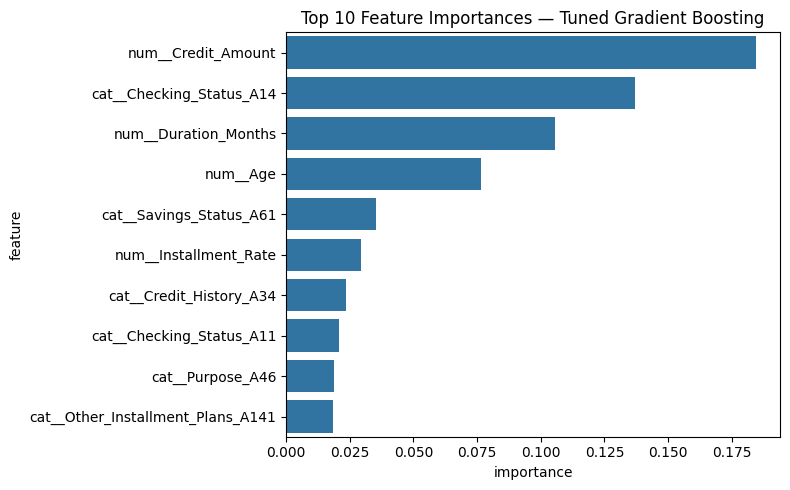

In [169]:
feature_names = preprocessor.get_feature_names_out()
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": best_gb_model.feature_importances_
}).sort_values("importance", ascending=False)

top_features = feature_importance.head(10)
plt.figure(figsize=(8,5))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 10 Feature Importances — Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

## 16. Saving the model

In [170]:
joblib.dump(
    best_gb_model,
    "final_gradient_boosting_model.pkl"
)
print("Final model saved successfully!")

Final model saved successfully!


In [171]:
import os
print(os.path.exists("final_gradient_boosting_model.pkl"))

True


In [172]:
print(type(best_gb_model))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [173]:
joblib.dump(
    best_gb_model,
    "/content/final_gradient_boosting_model.pkl"
)
print("Model saved successfully!")

Model saved successfully!


In [174]:
size = os.path.getsize("/content/final_gradient_boosting_model.pkl")
print("File size:", size, "bytes")

File size: 177624 bytes


In [175]:
model = joblib.load("/content/final_gradient_boosting_model.pkl")
print("Model loaded successfully!")
print(type(model))

Model loaded successfully!
<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


## 17. Multi-metrics Evaluation

Confusion Matrix

Confusion Matrix:
[[119  21]
 [ 30  30]]


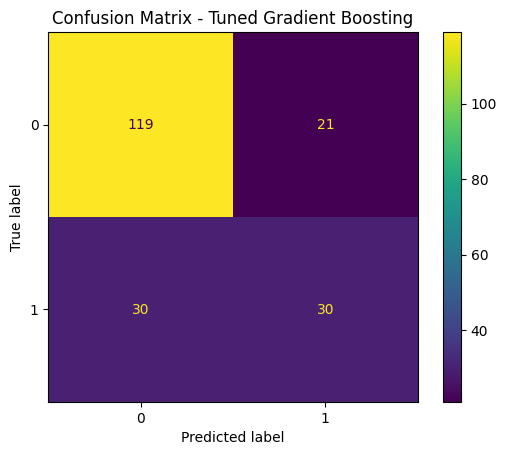

In [176]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Confusion Matrix - Tuned Gradient Boosting")
plt.show()

In [180]:
multi_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Cost-Weighted F1",
        "Expected Loss"
    ],
    "Tuned Gradient Boosting": [
        accuracy,
        precision,
        recall,
        f1,
        cost_weighted_f1,
        expected_loss
    ]
})

display(multi_metrics)

,Metric,Tuned Gradient Boosting
0,Accuracy,0.745000
1,Precision,0.693447
2,Recall,0.675000
3,F1 Score,0.682035
4,Cost-Weighted F1,0.587705
5,Expected Loss,0.855000
